# Sales and Revenue Analysis Dashboard

## Import Libraries

In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from ipywidgets import interact,widgets

## Load dataset 

In [34]:
df = pd.read_csv(
    "/home/rgukt-basar/sales_revenue_analysis_dashboard_project/data/sales_data_sample.csv",
    encoding='latin1'
)

In [35]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [36]:
df.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='object')

In [37]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [38]:
df.drop_duplicates(inplace=True)

In [39]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

## Key Performance Indicators(KPIs) creation

In [40]:
total_sales = df['SALES'].sum()
print(total_sales)

10032628.85


In [41]:
total_orders = df['ORDERNUMBER'].nunique()
print(total_orders)

307


In [42]:
total_quantity = df['QUANTITYORDERED'].sum()
print(total_quantity)

99067


In [43]:
avg_sales = df['SALES'].mean()
print(avg_sales)

3553.889071909316


In [44]:
top_product = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

print(top_product)

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64


## Monthly Sales Trend

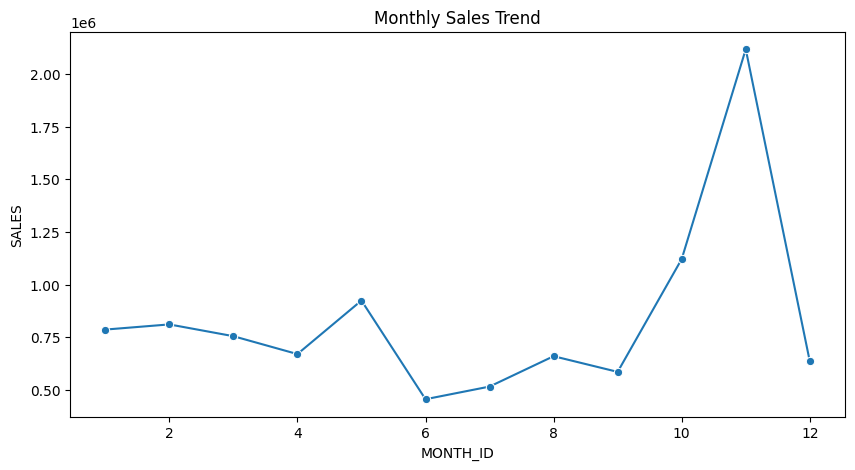

In [45]:
monthly_sales = df.groupby('MONTH_ID')['SALES'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x='MONTH_ID', y='SALES', marker='o')

plt.title('Monthly Sales Trend')
plt.xticks(rotation=0)
plt.show()

## Top Selling Products

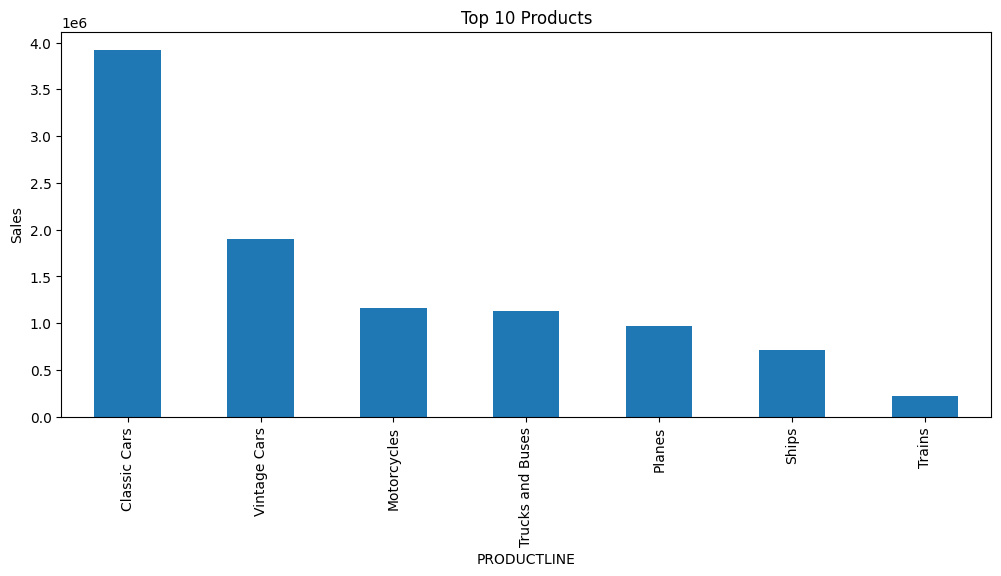

In [46]:
top_products = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(12,5))

plt.title('Top 10 Products')
plt.ylabel('Sales')
plt.show()

## Sales by Region

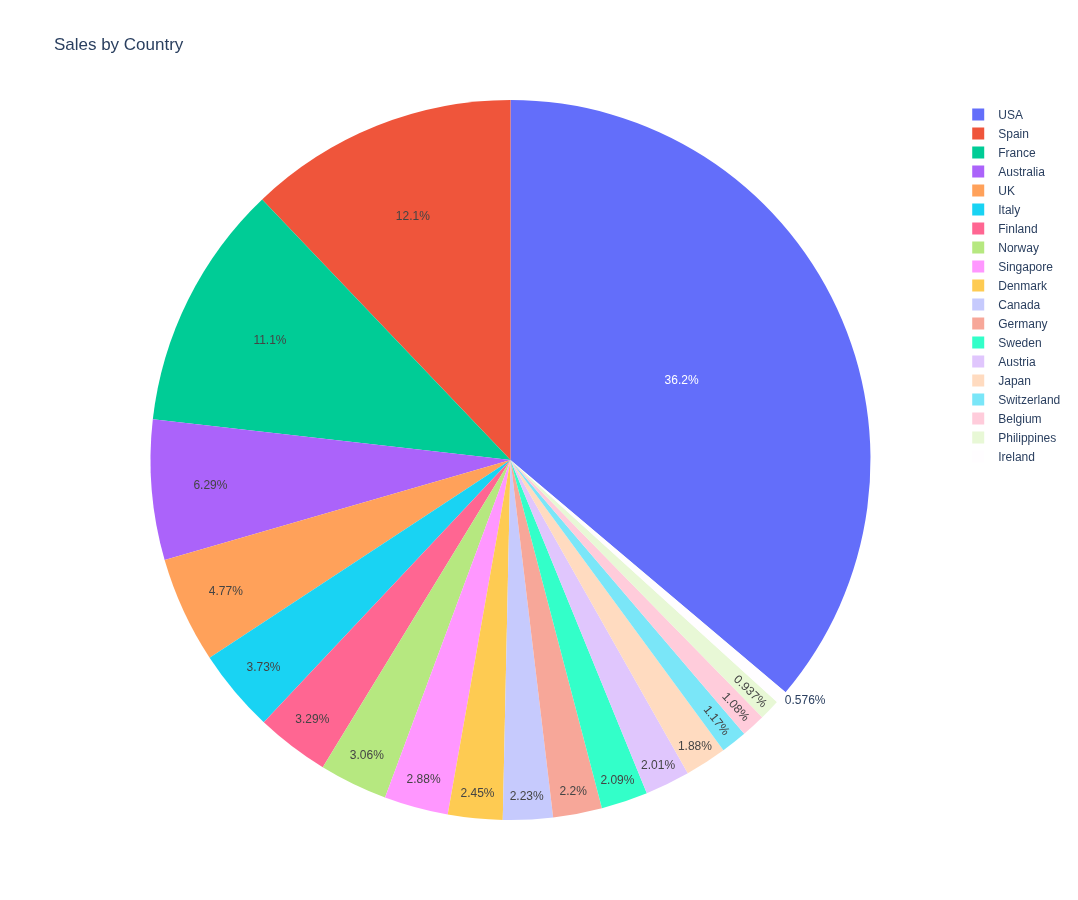

In [47]:
region_sales = df.groupby('COUNTRY')['SALES'].sum().reset_index()

import plotly.express as px

fig = px.pie(region_sales,
             names='COUNTRY',
             values='SALES',
             title='Sales by Country')

fig.update_layout(width=900, height=900)

fig.show()

## Interactive Filters

### Region Filter

In [48]:
from ipywidgets import interact
import matplotlib.pyplot as plt

@interact(region=df['COUNTRY'].unique())

def show_region_sales(region):

    filtered = df[df['COUNTRY'] == region]

    sales = filtered.groupby('PRODUCTLINE')['SALES'].sum()

    sales.plot(kind='bar', figsize=(10,5))

    plt.title(f'Sales in {region}')
    plt.xlabel('Product Line')
    plt.ylabel('Sales')

    plt.xticks(rotation=45)

    plt.show()

interactive(children=(Dropdown(description='region', options=('USA', 'France', 'Norway', 'Australia', 'Finland…

In [50]:
@interact(
    country=['All'] + sorted(df['COUNTRY'].dropna().unique().tolist()),
    year=['All'] + sorted(df['YEAR_ID'].dropna().unique().astype(str).tolist()),
    product_line=['All'] + sorted(df['PRODUCTLINE'].dropna().unique().tolist())
)

def interactive_dashboard(country, year, product_line):

    # Create copy
    filtered_df = df.copy()

    # Apply Country Filter
    if country != 'All':
        filtered_df = filtered_df[filtered_df['COUNTRY'] == country]

    # Apply Year Filter
    if year != 'All':
        filtered_df = filtered_df[filtered_df['YEAR_ID'] == int(year)]

    # Apply Product Line Filter
    if product_line != 'All':
        filtered_df = filtered_df[filtered_df['PRODUCTLINE'] == product_line]

    # =========================
    # KPI CALCULATIONS
    # =========================
    
    total_sales = filtered_df['SALES'].sum()
    total_orders = filtered_df['ORDERNUMBER'].nunique()
    total_quantity = filtered_df['QUANTITYORDERED'].sum()
    average_sales = filtered_df['SALES'].mean()

    print("="*50)
    print(" SALES & REVENUE DASHBOARD ")
    print("="*50)

    print(f"Total Sales: ${total_sales:,.2f}")
    print(f"Total Orders: {total_orders}")
    print(f"Total Quantity Sold: {total_quantity}")
    print(f"Average Sales: ${average_sales:,.2f}")

    # =========================
    # MONTHLY SALES TREND
    # =========================

    monthly_sales = filtered_df.groupby('MONTH_ID')['SALES'].sum()

    plt.figure(figsize=(12,5))
    sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')

    plt.title('Monthly Sales Trend')
    plt.xlabel('Month')
    plt.ylabel('Sales')
    plt.grid(True)

    plt.show()

    # =========================
    # TOP PRODUCT LINES
    # =========================

    top_products = (
        filtered_df.groupby('PRODUCTLINE')['SALES']
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12,6))
    sns.barplot(
        x=top_products.values,
        y=top_products.index
    )

    plt.title('Top Product Lines')
    plt.xlabel('Sales')
    plt.ylabel('Product Line')

    plt.show()

    # =========================
    # SALES BY COUNTRY
    # =========================

    country_sales = (
        filtered_df.groupby('COUNTRY')['SALES']
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12,6))
    sns.barplot(
        x=country_sales.values,
        y=country_sales.index
    )

    plt.title('Top Countries by Sales')
    plt.xlabel('Sales')
    plt.ylabel('Country')

    plt.show()

    # =========================
    # BUSINESS INSIGHTS
    # =========================

    print("\nBUSINESS INSIGHTS")
    print("-"*50)

    if not filtered_df.empty:

        best_product = (
            filtered_df.groupby('PRODUCTLINE')['SALES']
            .sum()
            .idxmax()
        )

        best_month = (
            filtered_df.groupby('MONTH_ID')['SALES']
            .sum()
            .idxmax()
        )

        best_country = (
            filtered_df.groupby('COUNTRY')['SALES']
            .sum()
            .idxmax()
        )

        print(f"Highest performing product line: {best_product}")
        print(f"Best sales month: Month {best_month}")
        print(f"Top revenue generating country: {best_country}")

    else:
        print("No data available for selected filters.")

interactive(children=(Dropdown(description='country', options=('All', 'Australia', 'Austria', 'Belgium', 'Cana…